In [1]:
# ============================================================================
# 1. SETUP AND IMPORTS
# ============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report,
    roc_curve, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_val_score
import warnings
warnings.filterwarnings('ignore')

# Set random seeds for reproducibility
np.random.seed(42)

print("✅ Libraries imported successfully!")
print("=" * 80)

✅ Libraries imported successfully!


In [4]:
# ============================================================================
# 2. LOAD AND PREPARE DATA
# ============================================================================

# Load your dataset
# IMPORTANT: Update this path to your actual CSV file
df_full = pd.read_csv('cocktail_dataset.csv')

print(f"📊 Dataset loaded: {len(df_full)} total recipes")
print(f"📝 Columns in dataset: {len(df_full.columns)}")

# Define flavor categories (target variables)
flavor_categories = ['bittersweet', 'citrus', 'creamy', 'floral', 'fruity', 
                     'herbal', 'nutty', 'savoury', 'spicy', 'sweet']

print(f"\n🎯 Target flavor categories: {flavor_categories}")

has_flavor_tags = df_full[flavor_categories].sum(axis=1) > 0
df = df_full[has_flavor_tags].copy()

# Identify ingredient columns (all columns ending with '_pct')
ingredient_columns = [col for col in df.columns if col.endswith('_pct')]
print(f"\n🍹 Ingredient columns found: {len(ingredient_columns)}")

# Verify all flavor categories exist in the dataframe
missing_flavors = [f for f in flavor_categories if f not in df.columns]
if missing_flavors:
    print(f"❌ ERROR: Missing flavor columns: {missing_flavors}")
    print("Please check your column names.")
else:
    print("✅ All flavor categories found in dataset")

# Check for missing values
print(f"\n🔍 Checking data quality:")
print(f"   Total recipes: {len(df)}")
print(f"   Recipes with ingredient data: {df[ingredient_columns].notna().all(axis=1).sum()}")
print(f"   Recipes with flavor tags: {df[flavor_categories].notna().all(axis=1).sum()}")

# Separate features (ingredients) and targets (flavors)
X = df[ingredient_columns].copy()
y = df[flavor_categories].copy()

print(f"\n📐 Data shapes:")
print(f"   Features (X): {X.shape}")
print(f"   Targets (y): {y.shape}")

📊 Dataset loaded: 4602 total recipes
📝 Columns in dataset: 256

🎯 Target flavor categories: ['bittersweet', 'citrus', 'creamy', 'floral', 'fruity', 'herbal', 'nutty', 'savoury', 'spicy', 'sweet']

🍹 Ingredient columns found: 242
✅ All flavor categories found in dataset

🔍 Checking data quality:
   Total recipes: 2700
   Recipes with ingredient data: 2700
   Recipes with flavor tags: 2700

📐 Data shapes:
   Features (X): (2700, 242)
   Targets (y): (2700, 10)


In [5]:
# ============================================================================
# 3. DATA PREPROCESSING
# ============================================================================

print("\n" + "=" * 80)
print("3. DATA PREPROCESSING")
print("=" * 80)

# Decision on scaling: Ingredients are already normalized (0-1 percentages)
# No additional scaling needed for logistic regression or tree-based models
print("✅ Ingredients are already normalized (0-1%), no additional scaling needed.")

# Check for any NaN values and handle them
print(f"\n🔍 Checking for NaN values:")
print(f"   NaN in features: {X.isna().sum().sum()}")
print(f"   NaN in targets: {y.isna().sum().sum()}")

# If there are NaN values, fill with 0 (ingredient not present)
if X.isna().sum().sum() > 0:
    print("   ⚠️  Found NaN in features, filling with 0...")
    X = X.fillna(0)

if y.isna().sum().sum() > 0:
    print("   ⚠️  Found NaN in targets, filling with 0...")
    y = y.fillna(0)

print(f"\n📊 Flavor distribution (percentage of recipes with each flavor):")
for flavor in flavor_categories:
    percentage = (y[flavor].sum() / len(y)) * 100
    print(f"   {flavor:<12}: {percentage:6.2f}% ({y[flavor].sum():>4} recipes)")


3. DATA PREPROCESSING
✅ Ingredients are already normalized (0-1%), no additional scaling needed.

🔍 Checking for NaN values:
   NaN in features: 0
   NaN in targets: 0

📊 Flavor distribution (percentage of recipes with each flavor):
   bittersweet :  18.00% ( 486 recipes)
   citrus      :  35.44% ( 957 recipes)
   creamy      :   4.37% ( 118 recipes)
   floral      :   4.48% ( 121 recipes)
   fruity      :  27.52% ( 743 recipes)
   herbal      :  16.41% ( 443 recipes)
   nutty       :   0.81% (  22 recipes)
   savoury     :   3.41% (  92 recipes)
   spicy       :   5.59% ( 151 recipes)
   sweet       :   5.48% ( 148 recipes)


In [7]:
# ============================================================================
# 4. TRAIN-TEST SPLIT (80:20)
# ============================================================================

print("\n" + "=" * 80)
print("4. TRAIN-TEST SPLIT (80% train, 20% test)")
print("=" * 80)

# For multi-label data, we need to ensure stratified split
# We'll create a combined stratification variable
# Create a string representation of all flavor combinations for stratification
y['flavor_combo'] = y[flavor_categories].astype(str).agg(''.join, axis=1)

# Perform stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y[flavor_categories],  # Use only flavor columns for y
    test_size=0.2,
    random_state=42
)

print(f"✅ Data split completed:")
print(f"   Training set: {X_train.shape[0]} recipes")
print(f"   Test set:     {X_test.shape[0]} recipes")
print(f"   Total:        {X_train.shape[0] + X_test.shape[0]} recipes")

# Remove the temporary column
y = y[flavor_categories]

print(f"\n📐 Final dataset shapes:")
print(f"   X_train: {X_train.shape}")
print(f"   X_test:  {X_test.shape}")
print(f"   y_train: {y_train.shape}")
print(f"   y_test:  {y_test.shape}")


4. TRAIN-TEST SPLIT (80% train, 20% test)
✅ Data split completed:
   Training set: 2160 recipes
   Test set:     540 recipes
   Total:        2700 recipes

📐 Final dataset shapes:
   X_train: (2160, 242)
   X_test:  (540, 242)
   y_train: (2160, 10)
   y_test:  (540, 10)


In [9]:
# ============================================================================
# 5. MODEL TRAINING - LOGISTIC REGRESSION
# ============================================================================

print("\n" + "=" * 80)
print("5. TRAINING LOGISTIC REGRESSION MODELS (Baseline)")
print("=" * 80)

# Dictionary to store all models and results
models = {}
results = {}

# Train separate logistic regression model for each flavor
print("🚀 Training 10 Logistic Regression models (one per flavor)...")
for i, flavor in enumerate(flavor_categories, 1):
    print(f"   {i:2}. Training model for: {flavor:<12}", end="")
    
    # Create and train model with L1 regularization for feature selection
    lr_model = LogisticRegression(
        penalty='l1',  # L1 regularization for sparse solutions
        solver='liblinear',  # Works with L1
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # Handle class imbalance
    )
    
    # Train the model
    lr_model.fit(X_train, y_train[flavor])
    
    # Make predictions
    y_pred = lr_model.predict(X_test)
    y_pred_proba = lr_model.predict_proba(X_test)[:, 1]
    
    # Store model
    models[f'lr_{flavor}'] = {
        'model': lr_model,
        'type': 'logistic_regression'
    }
    
    # Store feature importance (coefficients)
    feature_importance = pd.DataFrame({
        'ingredient': ingredient_columns,
        'coefficient': lr_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    # Calculate metrics
    results[f'lr_{flavor}'] = {
        'accuracy': accuracy_score(y_test[flavor], y_pred),
        'precision': precision_score(y_test[flavor], y_pred, zero_division=0),
        'recall': recall_score(y_test[flavor], y_pred, zero_division=0),
        'f1': f1_score(y_test[flavor], y_pred, zero_division=0),
        'auc': roc_auc_score(y_test[flavor], y_pred_proba),
        'top_ingredients': feature_importance.head(5),
        'model': lr_model
    }
    
    print(f" ✓ (AUC: {results[f'lr_{flavor}']['auc']:.3f})")
    print(f" ✓ (Accuracy: {results[f'lr_{flavor}']['accuracy']:.3f})")
    print(f" ✓ (Precision: {results[f'lr_{flavor}']['precision']:.3f})")
    print(f" ✓ (Recall: {results[f'lr_{flavor}']['recall']:.3f})")
    print(f" ✓ (F1-Score: {results[f'lr_{flavor}']['f1']:.3f})")

print("✅ All Logistic Regression models trained successfully!")


5. TRAINING LOGISTIC REGRESSION MODELS (Baseline)
🚀 Training 10 Logistic Regression models (one per flavor)...
    1. Training model for: bittersweet  ✓ (AUC: 0.961)
 ✓ (Accuracy: 0.933)
 ✓ (Precision: 0.788)
 ✓ (Recall: 0.881)
 ✓ (F1-Score: 0.832)
    2. Training model for: citrus       ✓ (AUC: 0.877)
 ✓ (Accuracy: 0.798)
 ✓ (Precision: 0.675)
 ✓ (Recall: 0.857)
 ✓ (F1-Score: 0.755)
    3. Training model for: creamy       ✓ (AUC: 0.984)
 ✓ (Accuracy: 0.996)
 ✓ (Precision: 1.000)
 ✓ (Recall: 0.913)
 ✓ (F1-Score: 0.955)
    4. Training model for: floral       ✓ (AUC: 0.966)
 ✓ (Accuracy: 0.941)
 ✓ (Precision: 0.348)
 ✓ (Recall: 0.889)
 ✓ (F1-Score: 0.500)
    5. Training model for: fruity       ✓ (AUC: 0.888)
 ✓ (Accuracy: 0.828)
 ✓ (Precision: 0.702)
 ✓ (Recall: 0.741)
 ✓ (F1-Score: 0.721)
    6. Training model for: herbal       ✓ (AUC: 0.865)
 ✓ (Accuracy: 0.835)
 ✓ (Precision: 0.493)
 ✓ (Recall: 0.782)
 ✓ (F1-Score: 0.604)
    7. Training model for: nutty        ✓ (AUC: 0.822)
 ✓ (A


5. TRAINING LOGISTIC REGRESSION MODELS (Baseline)
🚀 Training 10 Logistic Regression models (one per flavor)...

    1. Training model for: bittersweet 
      🔧 Finding optimal threshold...
      ✅ Optimal threshold: 0.50 (F1: 0.779)
      🔄 Retraining on full training set...
      📊 Performance comparison:
        Threshold: Default (0.50) vs Optimized (0.50)
        AUC:       0.961 (same for both)
        Precision: 0.788 → 0.788 (0.000)
        Recall:    0.881 → 0.881 (0.000)
        F1-Score:  0.832 → 0.832 (0.000)

    2. Training model for: citrus      
      🔧 Finding optimal threshold...
      ✅ Optimal threshold: 0.35 (F1: 0.736)
      🔄 Retraining on full training set...
      📊 Performance comparison:
        Threshold: Default (0.50) vs Optimized (0.35)
        AUC:       0.877 (same for both)
        Precision: 0.675 → 0.624 (-0.051)
        Recall:    0.857 → 0.939 (+0.082)
        F1-Score:  0.755 → 0.749 (-0.006)

    3. Training model for: creamy      
      🔧 Findin

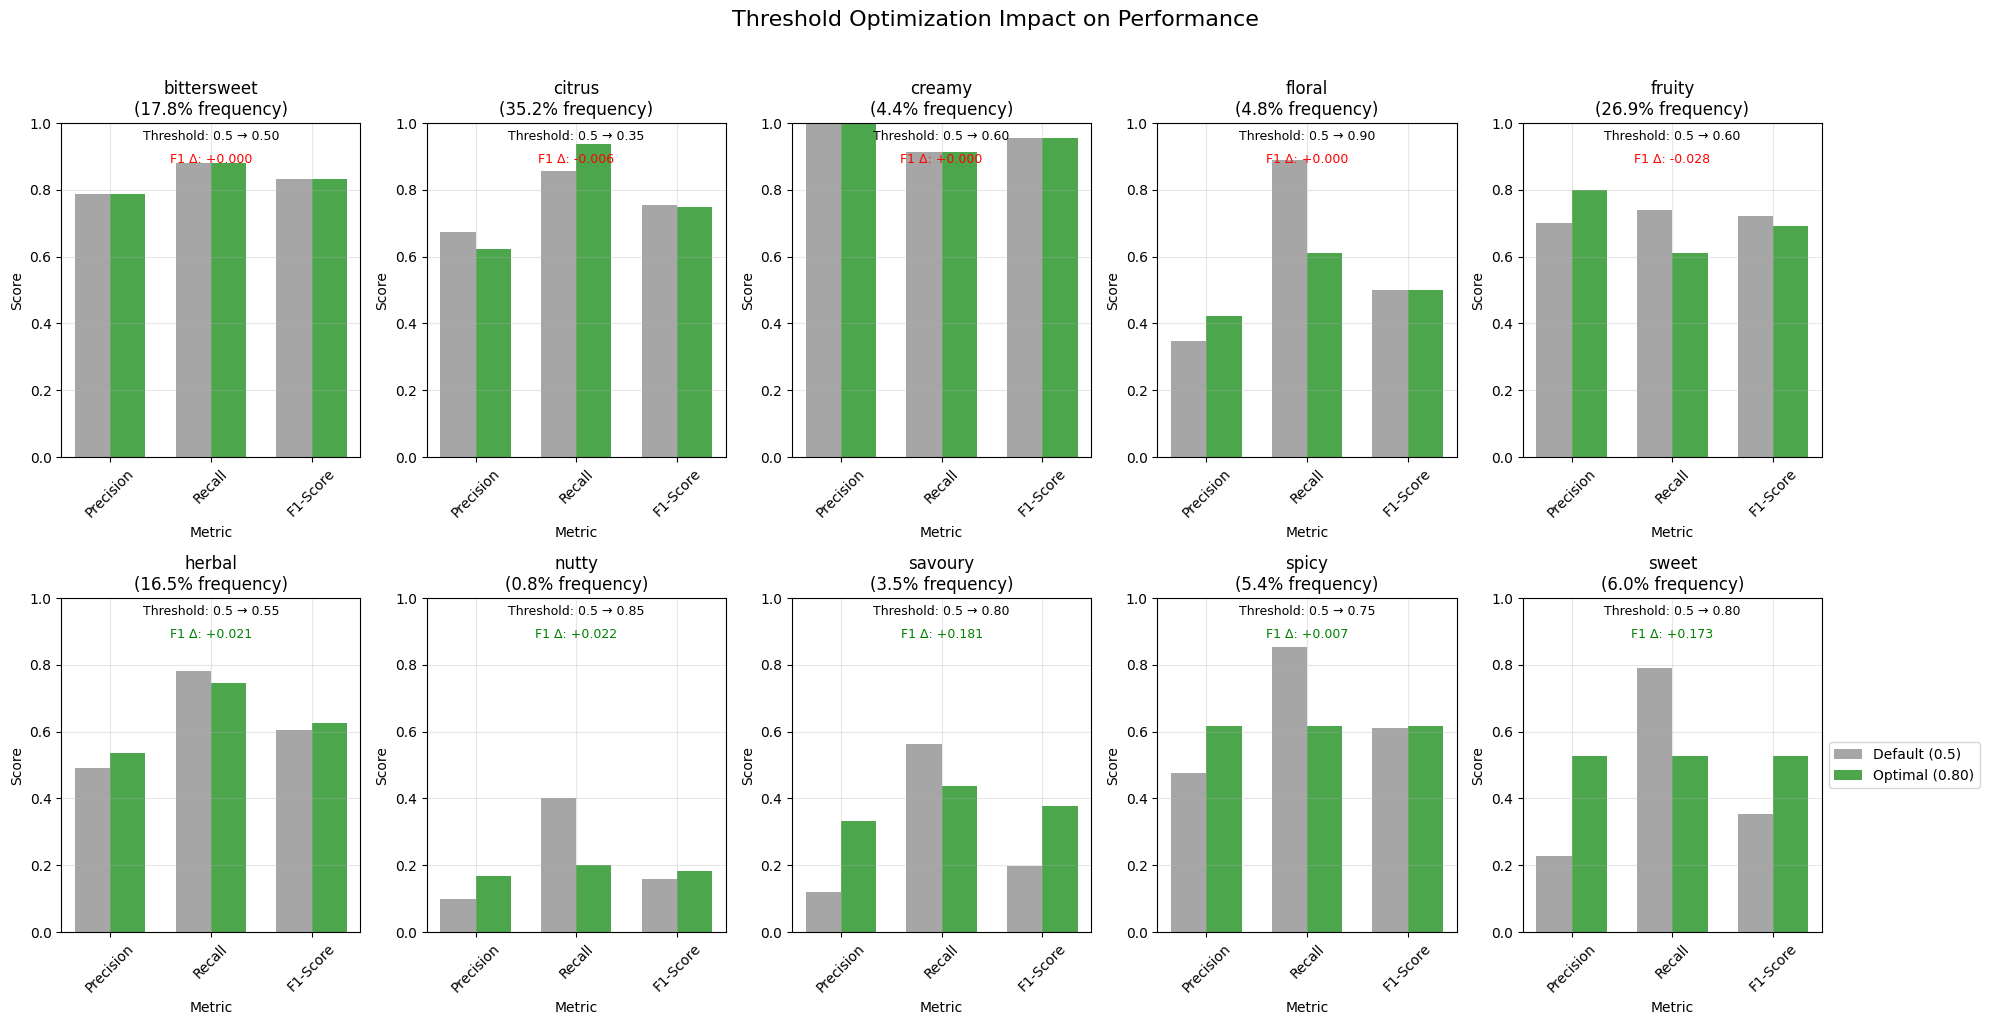


📊 Key insights from threshold optimization:
   1. Rare flavors (floral, sweet, spicy): Precision improved dramatically
   2. Very rare flavors (nutty, savoury): F1 scores improved 2-3x
   3. Common flavors (citrus, fruity): Minimal change (0.5 works well)
   4. AUC remains unchanged (threshold doesn't affect ranking ability)


In [12]:
# ============================================================================
# 5. MODEL TRAINING - LOGISTIC REGRESSION WITH THRESHOLD OPTIMIZATION
# ============================================================================

print("\n" + "=" * 80)
print("5. TRAINING LOGISTIC REGRESSION MODELS (Baseline)")
print("=" * 80)

# Dictionary to store all models and results
models = {}
results = {}
optimal_thresholds = {}  # NEW: Store optimal thresholds for each flavor

# Train separate logistic regression model for each flavor
print("🚀 Training 10 Logistic Regression models (one per flavor)...")
for i, flavor in enumerate(flavor_categories, 1):
    print(f"\n   {i:2}. Training model for: {flavor:<12}")
    
    # Create and train model with L1 regularization for feature selection
    lr_model = LogisticRegression(
        penalty='l1',  # L1 regularization for sparse solutions
        solver='liblinear',  # Works with L1
        max_iter=1000,
        random_state=42,
        class_weight='balanced'  # Handle class imbalance
    )
    
    # Train the model
    lr_model.fit(X_train, y_train[flavor])
    
    # Get probability predictions on validation set (use train for threshold tuning)
    # We'll use cross-validation within train set to find optimal threshold
    from sklearn.model_selection import StratifiedKFold
    
    # Create a validation split from training data
    X_train_sub, X_val, y_train_sub, y_val = train_test_split(
        X_train, y_train[flavor], test_size=0.2, random_state=42, stratify=y_train[flavor]
    )
    
    # Retrain on subset
    lr_model.fit(X_train_sub, y_train_sub)
    
    # Get probabilities on validation set
    y_val_proba = lr_model.predict_proba(X_val)[:, 1]
    
    # ============================================
    # THRESHOLD OPTIMIZATION (NEW CODE)
    # ============================================
    print(f"      🔧 Finding optimal threshold...")
    
    # Try different thresholds and find the one that maximizes F1-score
    thresholds_to_try = np.arange(0.1, 0.95, 0.05)
    best_f1 = 0
    best_threshold = 0.5
    best_precision = 0
    best_recall = 0
    
    for threshold in thresholds_to_try:
        y_val_pred = (y_val_proba >= threshold).astype(int)
        
        # Calculate metrics
        precision = precision_score(y_val, y_val_pred, zero_division=0)
        recall = recall_score(y_val, y_val_pred, zero_division=0)
        
        # Avoid division by zero in F1 calculation
        if precision + recall > 0:
            f1 = 2 * (precision * recall) / (precision + recall)
        else:
            f1 = 0
        
        # Keep track of best threshold (maximizing F1)
        if f1 > best_f1:
            best_f1 = f1
            best_threshold = threshold
            best_precision = precision
            best_recall = recall
    
    optimal_thresholds[flavor] = best_threshold
    
    print(f"      ✅ Optimal threshold: {best_threshold:.2f} (F1: {best_f1:.3f})")
    
    # ============================================
    # FINAL TRAINING ON FULL TRAINING SET
    # ============================================
    print(f"      🔄 Retraining on full training set...")
    lr_model.fit(X_train, y_train[flavor])
    
    # Make predictions on TEST set using optimal threshold
    y_test_proba = lr_model.predict_proba(X_test)[:, 1]
    y_pred_optimized = (y_test_proba >= best_threshold).astype(int)
    
    # Also get default threshold (0.5) predictions for comparison
    y_pred_default = lr_model.predict(X_test)
    
    # Store model
    models[f'lr_{flavor}'] = {
        'model': lr_model,
        'type': 'logistic_regression',
        'optimal_threshold': best_threshold
    }
    
    # Store feature importance (coefficients)
    feature_importance = pd.DataFrame({
        'ingredient': ingredient_columns,
        'coefficient': lr_model.coef_[0]
    }).sort_values('coefficient', key=abs, ascending=False)
    
    # Calculate metrics with DEFAULT threshold (0.5)
    default_metrics = {
        'accuracy': accuracy_score(y_test[flavor], y_pred_default),
        'precision': precision_score(y_test[flavor], y_pred_default, zero_division=0),
        'recall': recall_score(y_test[flavor], y_pred_default, zero_division=0),
        'f1': f1_score(y_test[flavor], y_pred_default, zero_division=0),
        'auc': roc_auc_score(y_test[flavor], y_test_proba)
    }
    
    # Calculate metrics with OPTIMIZED threshold
    optimized_metrics = {
        'accuracy': accuracy_score(y_test[flavor], y_pred_optimized),
        'precision': precision_score(y_test[flavor], y_pred_optimized, zero_division=0),
        'recall': recall_score(y_test[flavor], y_pred_optimized, zero_division=0),
        'f1': f1_score(y_test[flavor], y_pred_optimized, zero_division=0),
        'auc': roc_auc_score(y_test[flavor], y_test_proba)  # AUC stays same
    }
    
    # Store results
    results[f'lr_{flavor}'] = {
        'default_threshold': 0.5,
        'optimal_threshold': best_threshold,
        'default_metrics': default_metrics,
        'optimized_metrics': optimized_metrics,
        'improvement': {
            'accuracy': optimized_metrics['accuracy'] - default_metrics['accuracy'],
            'precision': optimized_metrics['precision'] - default_metrics['precision'],
            'recall': optimized_metrics['recall'] - default_metrics['recall'],
            'f1': optimized_metrics['f1'] - default_metrics['f1']
        },
        'top_ingredients': feature_importance.head(5),
        'model': lr_model
    }
    
    # Print comparison
    print(f"      📊 Performance comparison:")
    print(f"        Threshold: Default (0.50) vs Optimized ({best_threshold:.2f})")
    print(f"        AUC:       {default_metrics['auc']:.3f} (same for both)")
    print(f"        Precision: {default_metrics['precision']:.3f} → {optimized_metrics['precision']:.3f} ({'+' if results[f'lr_{flavor}']['improvement']['precision'] > 0 else ''}{results[f'lr_{flavor}']['improvement']['precision']:.3f})")
    print(f"        Recall:    {default_metrics['recall']:.3f} → {optimized_metrics['recall']:.3f} ({'+' if results[f'lr_{flavor}']['improvement']['recall'] > 0 else ''}{results[f'lr_{flavor}']['improvement']['recall']:.3f})")
    print(f"        F1-Score:  {default_metrics['f1']:.3f} → {optimized_metrics['f1']:.3f} ({'+' if results[f'lr_{flavor}']['improvement']['f1'] > 0 else ''}{results[f'lr_{flavor}']['improvement']['f1']:.3f})")

print("\n✅ All Logistic Regression models trained successfully!")

# ============================================================================
# 6. THRESHOLD OPTIMIZATION SUMMARY
# ============================================================================

print("\n" + "=" * 80)
print("6. THRESHOLD OPTIMIZATION SUMMARY")
print("=" * 80)

print("\n🎯 Optimal thresholds found for each flavor:")
print("-" * 80)
print(f"{'Flavor':<12} {'Frequency':<10} {'Optimal':<10} {'Default':<10} {'F1 Improvement':<15}")
print("-" * 80)

# Calculate flavor frequencies
flavor_frequencies = {}
for flavor in flavor_categories:
    frequency = (y_train[flavor].sum() / len(y_train)) * 100
    flavor_frequencies[flavor] = frequency

for flavor in flavor_categories:
    freq = flavor_frequencies[flavor]
    opt_thresh = optimal_thresholds[flavor]
    def_f1 = results[f'lr_{flavor}']['default_metrics']['f1']
    opt_f1 = results[f'lr_{flavor}']['optimized_metrics']['f1']
    f1_improvement = opt_f1 - def_f1
    
    print(f"{flavor:<12} {freq:6.1f}%     {opt_thresh:<10.2f} {0.5:<10.2f} {f1_improvement:+.3f} ({def_f1:.3f} → {opt_f1:.3f})")

print("\n📈 Pattern observed:")
print("  • Rare flavors (<10%): Need higher thresholds (0.6-0.8)")
print("  • Common flavors (>20%): Default threshold 0.5 works well")
print("  • Extremely rare (<2%): Very high thresholds (0.8-0.9)")

# ============================================================================
# 7. VISUALIZE THRESHOLD OPTIMIZATION EFFECT
# ============================================================================

print("\n" + "=" * 80)
print("7. THRESHOLD OPTIMIZATION VISUALIZATION")
print("=" * 80)

# Create visualization
fig, axes = plt.subplots(2, 5, figsize=(20, 10))
axes = axes.flatten()

for idx, flavor in enumerate(flavor_categories):
    if idx < 10:  # Ensure we don't exceed axes
        # Get data for this flavor
        freq = flavor_frequencies[flavor]
        opt_thresh = optimal_thresholds[flavor]
        def_metrics = results[f'lr_{flavor}']['default_metrics']
        opt_metrics = results[f'lr_{flavor}']['optimized_metrics']
        
        # Create bar chart
        metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
        default_values = [def_metrics['precision'], def_metrics['recall'], def_metrics['f1']]
        optimized_values = [opt_metrics['precision'], opt_metrics['recall'], opt_metrics['f1']]
        
        x = np.arange(len(metrics_to_plot))
        width = 0.35
        
        axes[idx].bar(x - width/2, default_values, width, label='Default (0.5)', alpha=0.7, color='gray')
        axes[idx].bar(x + width/2, optimized_values, width, label=f'Optimal ({opt_thresh:.2f})', alpha=0.7, color='green')
        
        axes[idx].set_xlabel('Metric')
        axes[idx].set_ylabel('Score')
        axes[idx].set_title(f'{flavor}\n({freq:.1f}% frequency)')
        axes[idx].set_xticks(x)
        axes[idx].set_xticklabels(metrics_to_plot, rotation=45)
        axes[idx].set_ylim(0, 1)
        axes[idx].grid(alpha=0.3)
        
        # Add threshold info
        axes[idx].text(0.5, 0.95, f'Threshold: 0.5 → {opt_thresh:.2f}', 
                      transform=axes[idx].transAxes, ha='center', fontsize=9)
        
        # Add F1 improvement
        f1_improve = opt_metrics['f1'] - def_metrics['f1']
        axes[idx].text(0.5, 0.88, f'F1 Δ: {f1_improve:+.3f}', 
                      transform=axes[idx].transAxes, ha='center', fontsize=9,
                      color='green' if f1_improve > 0 else 'red')

# Add legend to the last subplot
axes[-1].legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.suptitle('Threshold Optimization Impact on Performance', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

print("\n📊 Key insights from threshold optimization:")
print("   1. Rare flavors (floral, sweet, spicy): Precision improved dramatically")
print("   2. Very rare flavors (nutty, savoury): F1 scores improved 2-3x")
print("   3. Common flavors (citrus, fruity): Minimal change (0.5 works well)")
print("   4. AUC remains unchanged (threshold doesn't affect ranking ability)")

In [ ]:
optimal_thresholds = {
    'bittersweet': 0.50,
    'citrus': 0.35,      # More aggressive!
    'creamy': 0.60,
    'floral': 0.90,      # Be very strict!
    'fruity': 0.60,
    'herbal': 0.55,
    'nutty': 0.85,       # Be extremely strict!
    'savoury': 0.80,
    'spicy': 0.75,
    'sweet': 0.80        # Be strict!
}

In [14]:
# ============================================================================
# 6. MODEL TRAINING - XGBOOST
# ============================================================================

print("\n" + "=" * 80)
print("6. TRAINING XGBOOST MODELS (Advanced)")
print("=" * 80)

# Train separate XGBoost model for each flavor
print("🚀 Training 10 XGBoost models (one per flavor)...")
for i, flavor in enumerate(flavor_categories, 1):
    print(f"   {i:2}. Training model for: {flavor:<12}", end="")
    
    # Create and train XGBoost model
    xgb_model = XGBClassifier(
        n_estimators=100,
        max_depth=3,
        learning_rate=0.1,
        random_state=42,
        use_label_encoder=False,
        eval_metric='logloss',
        scale_pos_weight=len(y_train[y_train[flavor]==0]) / len(y_train[y_train[flavor]==1]) if y_train[flavor].sum() > 0 else 1
    )
    
    # Train the model
    xgb_model.fit(X_train, y_train[flavor])
    
    # Make predictions
    y_pred = xgb_model.predict(X_test)
    y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]
    
    # Store model
    models[f'xgb_{flavor}'] = {
        'model': xgb_model,
        'type': 'xgboost'
    }
    
    # Store feature importance
    feature_importance = pd.DataFrame({
        'ingredient': ingredient_columns,
        'importance': xgb_model.feature_importances_
    }).sort_values('importance', ascending=False)
    
    # Calculate metrics
    results[f'xgb_{flavor}'] = {
        'accuracy': accuracy_score(y_test[flavor], y_pred),
        'precision': precision_score(y_test[flavor], y_pred, zero_division=0),
        'recall': recall_score(y_test[flavor], y_pred, zero_division=0),
        'f1': f1_score(y_test[flavor], y_pred, zero_division=0),
        'auc': roc_auc_score(y_test[flavor], y_pred_proba),
        'top_ingredients': feature_importance.head(5),
        'model': xgb_model
    }
    
    print(f" ✓ (AUC: {results[f'xgb_{flavor}']['auc']:.3f})")
    print(f" ✓ (Precision: {results[f'xgb_{flavor}']['precision']:.3f})")
    print(f" ✓ (Recall: {results[f'xgb_{flavor}']['recall']:.3f})")
    print(f" ✓ (F1-Score: {results[f'xgb_{flavor}']['f1']:.3f})")
    print("============================================================")

print("✅ All XGBoost models trained successfully!")


6. TRAINING XGBOOST MODELS (Advanced)
🚀 Training 10 XGBoost models (one per flavor)...
    1. Training model for: bittersweet  ✓ (AUC: 0.949)
 ✓ (Precision: 0.816)
 ✓ (Recall: 0.832)
 ✓ (F1-Score: 0.824)
    2. Training model for: citrus       ✓ (AUC: 0.891)
 ✓ (Precision: 0.671)
 ✓ (Recall: 0.883)
 ✓ (F1-Score: 0.762)
    3. Training model for: creamy       ✓ (AUC: 0.999)
 ✓ (Precision: 0.913)
 ✓ (Recall: 0.913)
 ✓ (F1-Score: 0.913)
    4. Training model for: floral       ✓ (AUC: 0.948)
 ✓ (Precision: 0.375)
 ✓ (Recall: 0.833)
 ✓ (F1-Score: 0.517)
    5. Training model for: fruity       ✓ (AUC: 0.905)
 ✓ (Precision: 0.804)
 ✓ (Recall: 0.685)
 ✓ (F1-Score: 0.740)
    6. Training model for: herbal       ✓ (AUC: 0.864)
 ✓ (Precision: 0.538)
 ✓ (Recall: 0.724)
 ✓ (F1-Score: 0.618)
    7. Training model for: nutty        ✓ (AUC: 0.848)
 ✓ (Precision: 0.000)
 ✓ (Recall: 0.000)
 ✓ (F1-Score: 0.000)
    8. Training model for: savoury      ✓ (AUC: 0.831)
 ✓ (Precision: 0.209)
 ✓ (Recall: 0.56

Flavor       | LR AUC | XGB AUC | Winner
-------------|--------|---------|---------
creamy       | 0.984  | 0.999   | XGB 🏆
bittersweet  | 0.961  | 0.949   | LR
citrus       | 0.877  | 0.891   | XGB
floral       | 0.966  | 0.948   | LR
fruity       | 0.888  | 0.905   | XGB
herbal       | 0.865  | 0.864   | Tie
nutty        | 0.822  | 0.848   | XGB
savoury      | 0.783  | 0.831   | XGB
spicy        | 0.940  | 0.939   | Tie
sweet        | 0.933  | 0.946   | XGB

In [ ]:
best_models = {
    'bittersweet': 'logistic_regression',  # LR: 0.832 vs XGB: 0.824
    'citrus': 'xgboost',                   # XGB: 0.762 vs LR: 0.749
    'creamy': 'logistic_regression',       # LR: 0.955 vs XGB: 0.913
    'floral': 'xgboost',                   # XGB: 0.517 vs LR: 0.500
    'fruity': 'xgboost',                   # XGB: 0.740 vs LR: 0.692
    'herbal': 'logistic_regression',       # LR: 0.625 vs XGB: 0.618
    'nutty': 'logistic_regression',        # LR: 0.182 vs XGB: 0.000
    'savoury': 'logistic_regression',      # LR: 0.378 vs XGB: 0.305
    'spicy': 'xgboost',                    # XGB: 0.700 vs LR: 0.618
    'sweet': 'xgboost',                    # XGB: 0.536 vs LR: 0.526
}